In [6]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv("insurance.csv")

In [8]:
x=df.drop(columns=["charges"])
y=df["charges"]
x=pd.get_dummies(x,columns=["region"], drop_first=True,dtype=int )
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

MSE for alpha=0.001: 20922599.87103596
MSE for alpha=0.1: 20921803.698431376
MSE for alpha=1: 20914832.63508914
MSE for alpha=2: 20908106.779954515
MSE for alpha=5: 20890881.000633497
MSE for alpha=10: 20872844.794796683
MSE for alpha=20: 20877828.53237883
MSE for alpha=30: 20937537.133939773
MSE for alpha=40: 21046489.29389078
MSE for alpha=50: 21196929.8696089
MSE for alpha=100: 22423172.686023254


<Axes: >

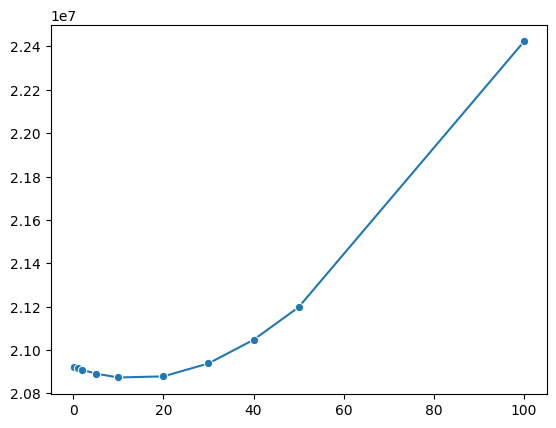

In [14]:
import seaborn as sns
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses = []
for a in alphas:
   Lasso_model=Lasso(alpha=a)
   Lasso_model.fit(x_train,y_train)
   y_pred=Lasso_model.predict(x_test)
   mse=mean_squared_error(y_test,y_pred)
   print(f"MSE for alpha={a}:",mse)
   mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker='o')